
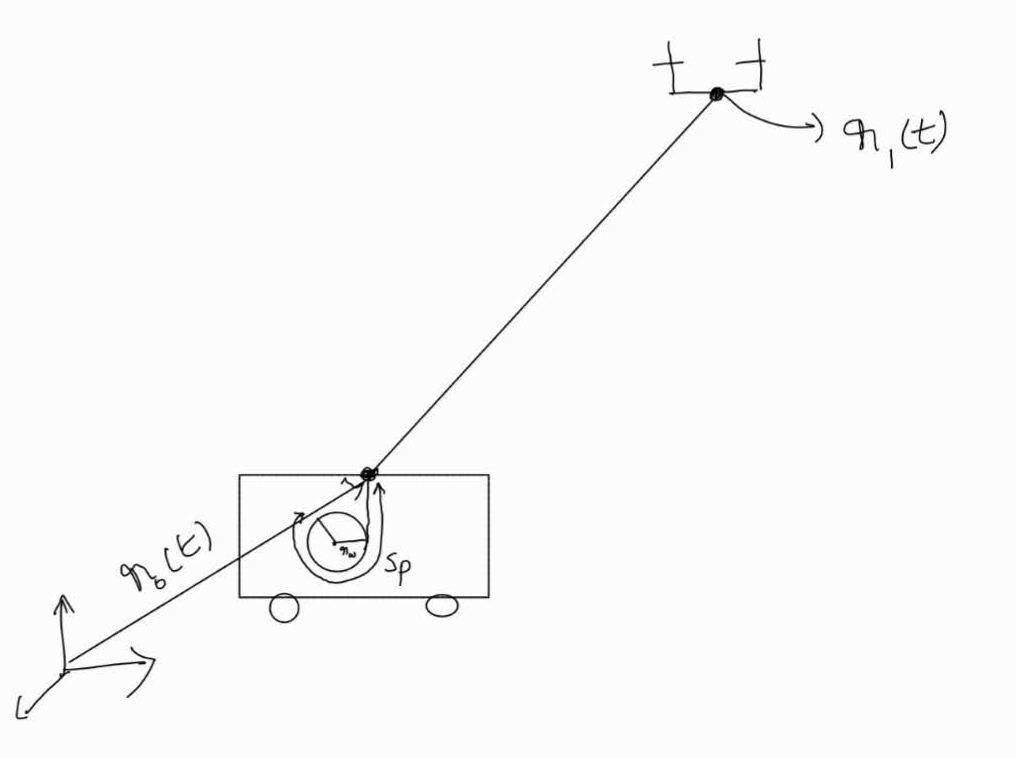

In [21]:
import sympy as sp

# Variables
s, t = sp.symbols('s t', real=True)
s_p, L = sp.symbols('sp L', real=True)
m_d , mu ,kappa ,m_v,g , EA= sp.symbols('m_d mu kappa m_v g EA ', real=True)


s_p = sp.Function('s_p')(t)
# Vector functions r0(t), r1(t) in 3D (change dimension as needed)
r0x, r0y, r0z = sp.Function('r0x')(t), sp.Function('r0y')(t), sp.Function('r0z')(t)
r1x, r1y, r1z = sp.Function('r1x')(t), sp.Function('r1y')(t), sp.Function('r1z')(t)

r0 = sp.Matrix([r0x, r0y, r0z])
r1 = sp.Matrix([r1x, r1y, r1z])

a1 = sp.Matrix([
    sp.Function('a1x')(t),
    sp.Function('a1y')(t),
    sp.Function('a1z')(t)
])

a2 = sp.Matrix([
    sp.Function('a2x')(t),
    sp.Function('a2y')(t),
    sp.Function('a2z')(t)
])

a3 = sp.Matrix([
    sp.Function('a3x')(t),
    sp.Function('a3y')(t),
    sp.Function('a3z')(t)
])


Define the deployed length
$$
\ell(t) = L - s_p(t).
$$

Approximate the tether centerline $r(s,t)\in\mathbb{R}^3$ by a linear interpolation between the vehicle attachment point $r_0(t)$ and the drone position $r_1(t)$:
$$
r(s,t) = \left(1-\frac{s}{\ell}\right) r_0(t) + \frac{s}{\ell}\, r_1(t),
\qquad s\in[s_p,\,L].
$$
The tether velocity is
$$
\dot r(s,t) = \frac{\partial r}{\partial t}(s,t),
$$
and the distributed kinetic energy is
$$
T_{\text{string}}
= \frac{1}{2}\mu \int_{s_p}^{L} \dot r(s,t)^\top \dot r(s,t)\, ds
= \frac{1}{2}\mu \int_{s_p}^{L} \|\dot r(s,t)\|^2\, ds.
$$
**Note.** Here we approximate the tether shape using a *linear interpolation* (a single basis function) between the boundary points $r_0(t)$ and $r_1(t)$ wich is equaivalant to 1-link tether model:
$$
r_{\text{lin}}(s,t) = \left(1-\frac{s}{\ell}\right) r_0(t) + \frac{s}{\ell}\, r_1(t), 
\qquad \ell(t)=L-s_p(t).
$$
This provides a minimal model that captures the moving-boundary effect through $\ell(t)$.

Later we can modify  this approximation by expanding $r(s,t)$ in a higher-order basis to capture tether curvature and vibration modes, e.g.
$$
r(s,t) \approx r_{\text{lin}}(s,t) + \sum_{k=1}^{N} a_k(t)\,\phi_k(s),
$$
with mode shapes $\phi_k(s)$ chosen from a physically motivated set (e.g., combinations of $\cosh(\cdot)$, $\sinh(\cdot)$, $\cos(\cdot)$, and $\sin(\cdot)$).Alternatively, the basis functions $\{\phi_k\}$ may be obtained **directly from experimentas**

For example, a $\cosh(\cdot)$ basis can represent the quasi-static **catenary curve** of the tether under gravity, while $\sin(\cdot)$ and $\cos(\cdot)$ terms naturally capture higher-order **vibration modes**.

Each modal coefficient $a_k(t)\in\mathbb{R}^3$ introduces **three additional degrees of freedom** to the model, allowing the tether shape to be represented with increasing fidelity as more modes are included.



In [23]:
l = L - s_p
phi1 = sp.sin(sp.pi*s/l)
phi2 = sp.sin(2*sp.pi*s/l)
phi3 = sp.sin(3*sp.pi*s/l)
# r(s,t)
# r = (1 - s/l)*r0 + (s/l)*r1
r_lin = (1 - s/l)*r0 + (s/l)*r1

r = r_lin + a1*phi1 + a2*phi2 + a3*phi3
rdot = sp.diff(r, t)
norm_sq = sp.simplify(rdot.dot(rdot))
# norm_sq = (rdot.T * rdot)[0]

Ke_string = sp.Rational(1, 2) *mu* sp.integrate(norm_sq, (s, 0, l))
Ke_string

KeyboardInterrupt: 

Let $r_1(t) \in \mathbb{R}^3$ denote the position of the drone.
Its velocity is
$$
\dot r_1 = \frac{d r_1}{d t}.
$$

The translational kinetic energy of the drone is
$$
T_{\text{drone}}
= \frac{1}{2} m_d \, \dot r_1^\top \dot r_1
= \frac{1}{2} m_d \, \| \dot r_1 \|^2.
$$


In [ ]:
r1_dot = sp.diff(r1,t)
Ke_drone = sp.Rational(1, 2) * m_d*(r1_dot.T * r1_dot)[0]
Ke_drone

Let $s_p(t)$ denote the deployed tether length, with rate $\dot s_p$.
The kinetic energy associated with the winch and the tether wound on it is


$$
T_{\text{winch}} = \frac{1}{2}\left(\mu s_p + \kappa\right)\,\dot{s}_p^{\,2},
$$
where the winch inertia is related by
$
I = \kappa r^2,
$
and $\mu s_p$ represents the effective mass of tether wound on the winch.


In [ ]:
sp_dot = sp.diff(s_p,t)
Ke_winch = sp.Rational(1, 2) * (mu*s_p + kappa ) * sp_dot**2
Ke_winch

Let $r_0(t) \in \mathbb{R}^3$ denote the position of the ground vehicle.
Its velocity is
$$
\dot r_0 = \frac{d r_0}{d t}.
$$

The translational kinetic energy of the vehicle is
$$
T_{\text{vehicle}}
= \frac{1}{2} m_v \, \dot r_0^\top \dot r_0
= \frac{1}{2} m_v \, \| \dot r_0 \|^2.
$$


In [ ]:
r0_dot = sp.diff(r0,t)
Ke_vehicle = sp.Rational(1, 2) * m_v* (r0_dot.T * r0_dot)[0]
Ke_vehicle

The gravitational potential energy of the drone is
$$
V_{\text{drone}} = - m_d g \, r_{1z},
$$

The gravitational potential energy of the ground vehicle and the tether accumulated on the winch is
$$
V_{\text{vehicle}}
= - \left( m_v + \mu s_p \right) g \, r_{0z},
$$



In [ ]:
V_drone = -m_d * g * r1z

V_vehicle = -(m_v + mu * s_p)* g * r0z   #included  tether on winch


Let $r(s) \in \mathbb{R}^3$ denote the centerline of the tether parameterized by arc coordinate $s$.
The local stretch is
$$
\lambda(s) = \left\| \frac{\partial r}{\partial s} \right\|
= \sqrt{\left( \frac{\partial r}{\partial s} \right)^\top 
       \left( \frac{\partial r}{\partial s} \right)}.
$$
The total elastic energy stored in the tether segment $s \in [s_p,\, L]$ is
$$
V_{\text{elastic}}
= \int_{s_p}^{L} \frac{1}{2} EA \left( \lambda(s) - 1 \right)^2 \, ds.
$$
The gravitational potential energy is
$$
V_{\text{grav}}
= - \int_{s_p}^{L} \mu g \, r_{1z}(s) \, ds,
$$



In [ ]:
drds = sp.diff(r,s)

lam = sp.sqrt((drds.T * drds)[0])
# elastic energy density
integrand = sp.Rational(1,2) * EA * (lam - 1)**2

# integrate
V_elastic = sp.integrate(integrand, (s, 0, L-s_p))
V_grav = -sp.integrate(mu *g * r[2], (s, 0, L-s_p))
V_string = V_elastic + V_grav
sp.simplify(V_string)

The total kinetic energy of the coupled drone–tether–vehicle–winch system is
$$
T = T_{\text{drone}} + T_{\text{string}} + T_{\text{vehicle}} + T_{\text{winch}},
$$
that is,
$$
T
= \frac{1}{2} m_d \, \dot r_1^\top \dot r_1
+ \frac{1}{2} \mu \int_{s_p}^{L} \dot r(s,t)^\top \dot r(s,t)\, ds
+ \frac{1}{2} m_v \, \dot r_0^\top \dot r_0
+ \frac{1}{2} (\mu s_p + \kappa)\, \dot s_p^{\,2}.
$$

The total potential energy of the system is
$$
V = V_{\text{drone}} + V_{\text{vehicle}} + V_{\text{string}},
$$
that is,
$$
V
= - m_d g \, r_{1z}
  - \left( m_v + \mu s_p \right) g \, r_{0z}
  + \int_{s_p}^{L} \left[
      \frac{1}{2} EA \left( \lambda(s) - 1 \right)^2
      - \mu g \, r_3(s)
    \right] ds.
$$


In [ ]:
KE = Ke_drone + Ke_string + Ke_vehicle + Ke_winch
PE = V_drone + V_vehicle + V_string

Define the generalized coordinates as
$$
q(t) =
\begin{bmatrix}
r_{0x} & r_{0y} & r_{0z} &
r_{1x} & r_{1y} & r_{1z} &
s_p
\end{bmatrix}^\top,
$$
with generalized velocities and accelerations
$$
\dot q = \frac{d q}{d t}, 
\qquad 
\ddot q = \frac{d^2 q}{d t^2}.
$$
The Lagrangian of the system is
$$
\mathcal{L}(q,\dot q) = T(q,\dot q) - V(q).
$$
The equations of motion are obtained from the Euler–Lagrange equations
$$
\frac{d}{d t} \left( \frac{\partial \mathcal{L}}{\partial \dot q_i} \right)
- \frac{\partial \mathcal{L}}{\partial q_i}
= 0,
\qquad i = 1,\dots,7.
$$


In [ ]:
import sympy as sp


q = sp.Matrix([r0x, r0y, r0z, r1x, r1y, r1z, s_p])
qd  = q.diff(t)
qdd = qd.diff(t)

Lag = KE - PE

def EL_eq(L, qi):
    return sp.diff(sp.diff(L, sp.diff(qi, t)), t) - sp.diff(L, qi)

# Euler–Lagrange
EL = sp.Matrix([EL_eq(Lag, qi) for qi in q])




Collecting the Euler–Lagrange equations in vector form,
$$
\mathcal{E}(q,\dot q,\ddot q)
= \frac{d}{dt}\left(\frac{\partial \mathcal{L}}{\partial \dot q}\right)
- \frac{\partial \mathcal{L}}{\partial q}
= 0,
$$
we identify the mass matrix as the Jacobian with respect to the generalized accelerations:
$$
M(q) = \frac{\partial \mathcal{E}}{\partial \ddot q}.
$$


In [ ]:
Ms = sp.simplify(EL.jacobian(qdd))

Setting $\ddot q = 0$ yields the remaining terms
$$
B(q,\dot q) = \mathcal{E}(q,\dot q,0).
$$

Setting further $\dot q = 0$ isolates the gravity vector
$$
G(q) = B(q,0),
$$
and the remaining terms define the Coriolis/centrifugal contribution
$$
C(q,\dot q)\dot q = B(q,\dot q) - G(q).
$$


In [ ]:
qdd_zero = {qdi: 0 for qdi in qdd}
qdd_zero
u_repl = dict(zip(qd, sp.zeros(7,1)))
B = EL.xreplace(qdd_zero)
G = sp.simplify(B.xreplace(u_repl))
C = sp.simplify(B-G)


The equations of motion can therefore be written in standard form as
$$
M(q)\,\ddot q + C(q,\dot q)\,\dot q + G(q) = 0.
$$


At this stage, the model includes only conservative dynamics. 
External forces, control inputs, and drone attitude dynamics will be incorporated later through generalized forces,
$$
M(q)\ddot q + C(q,\dot q)\dot q + G(q) = Q(q,\dot q,u),
$$
where $Q$ collects thrust, aerodynamic forces, winch actuation, and attitude–translation coupling terms.


In [ ]:
# plain symbols for numerical state
f = -C - G
print(f.shape)
q_syms  = sp.symbols('q0:%d'  % len(q))
qd_syms = sp.symbols('qd0:%d' % len(q))
params = (L, m_d, mu, kappa, m_v, g, EA)
subs_q = {}
for i in range(len(q)):
    subs_q[q[i]]              = q_syms[i]
    subs_q[sp.diff(q[i], t)] = qd_syms[i]

M_num = Ms.subs(subs_q)
f_num = f.subs(subs_q)

# substitute q, qd by symbols as before
M_num = Ms.subs(subs_q)
f_num = f.subs(subs_q)

M_func = sp.lambdify((q_syms, qd_syms, params), M_num, 'numpy')
f_func = sp.lambdify((q_syms, qd_syms, params), f_num, 'numpy')

The full state vector is chosen as
$$
x =
\begin{bmatrix}
q \\ \dot q \\ \mathbf{q} \\ \boldsymbol\omega
\end{bmatrix},
\qquad
q \in \mathbb{R}^7,\;
\mathbf{q}\in\mathbb{S}^3,\;
\boldsymbol\omega\in\mathbb{R}^3,
$$
where  

- $q = \{ r_0, r_1, s_p \}$  are the translational and winch coordinates,  
- $ \mathbf{q} = [q_x,q_y,q_z,q_w]^\top$  is the unit quaternion representing drone attitude,  
- $ \boldsymbol\omega $ is the body angular velocity.

The external inputs are
$$
F_0 \in \mathbb{R}^3 \quad \text{(vehicle force)}, \qquad
\tau_{\text{winch}} \in \mathbb{R} \quad \text{(winch torque)},
$$
$$
F_{\text{thrust}} \in \mathbb{R} \quad \text{(body-$z$ thrust)}, \qquad
\tau_\omega \in \mathbb{R}^3 \quad \text{(body torque)}.
$$
The translational dynamics are written in generalized-coordinate form as
$$
M(q)\ddot q + C(q,\dot q)\dot q + G(q) = Q(q,\dot q,u),
$$
or equivalently,
$$
\ddot q = M(q)^{-1} \, (Q(q,\dot q,u)+F_{nle}),
$$
where ,$$F_{nle} = -C(q,\dot q)\,\dot q - G(q)$$
where the generalized force vector is assembled as
$$
Q =
\begin{bmatrix}
F_0 \\
F_{\text{thrust}}^{\text{world}} \\
\tau_{\text{winch}} / r_w
\end{bmatrix}.
$$
The attitude is represented by a unit quaternion $\mathbf{q} \in \mathbb{S}^3$.
The quaternion kinematics are
$$
\dot{\mathbf{q}} = \frac{1}{2} \, \mathbf{q} \otimes
\begin{bmatrix}
\boldsymbol\omega \\ 0
\end{bmatrix},
$$
where $\otimes$ denotes quaternion multiplication.
The rigid-body rotational dynamics of the drone are
$$
J \dot{\boldsymbol\omega}
= \tau_\omega - \boldsymbol\omega \times (J \boldsymbol\omega),
$$
or equivalently,
$$
\dot{\boldsymbol\omega}
= J^{-1}\left( \tau_\omega - \boldsymbol\omega \times (J \boldsymbol\omega) \right).
$$
The complete state-space model is
$$
\begin{aligned}
\dot q &= \dot q, \\
\ddot q &= M(q)^{-1} Q(q,\dot q,u), \\
\dot{\mathbf{q}} &= \tfrac12 \mathbf{q} \otimes [\boldsymbol\omega,0], \\
\dot{\boldsymbol\omega} &= J^{-1}\left( \tau_\omega - \boldsymbol\omega \times (J \boldsymbol\omega) \right).
\end{aligned}
$$
**Remark 1(Quaternion normalization).**  
To prevent numerical drift and preserve the unit-norm constraint of the attitude representation, the quaternion is renormalized at each integration step as
$$
\mathbf{q} \leftarrow \frac{\mathbf{q}}{\|\mathbf{q}\|}.
$$
This ensures that $\mathbf{q} \in \mathbb{S}^3$ remains a unit quaternion and continues to represent a valid rotation throughout the simulation.

**Remark 2 (Vehicle force balancing).**  
In order to prevent significant motion of the ground vehicle, its mass is chosen sufficiently large and an upward force is applied to approximately balance its weight,
$$
F_0 \approx m_v g \, \mathbf{e}_z.
$$
This effectively constrains the vehicle to remain nearly stationary, allowing the simulation to focus on the coupled drone–tether–winch dynamics rather than on vehicle motion.



In [ ]:
from scipy.spatial.transform import Rotation
import numpy as np
def input_func(t, x):
    # Ground_vehicle force ,  increase mass of vehicle and balance its weight to not move vehicke much
    F0 = np.array([0.0, 0.0, 500*9.81])

    # winch force (acts on s_p DOF)
    tau_winch = 0.0

    #thrust
    Fthrust = 120

    #drone torque
    Tau_omega = np.zeros(3)

    return F0, tau_winch, Fthrust, Tau_omega

def quat_mul_xyzw(q, p):
    """
    Quaternion multiplication q ⊗ p
    Both in [x, y, z, w] ordering.
    Returns [x, y, z, w].
    """
    x1, y1, z1, w1 = q
    x2, y2, z2, w2 = p

    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,   # x
        w1*y2 - x1*z2 + y1*w2 + z1*x2,   # y
        w1*z2 + x1*y2 - y1*x2 + z1*w2,   # z
        w1*w2 - x1*x2 - y1*y2 - z1*z2    # w
    ])
def quat_mul_q_omega(quat, omega):
    """
    Compute q ⊗ [omega, 0]

    quat  : [x, y, z, w]
    omega : [wx, wy, wz]

    returns q ⊗ omega_quat in [x, y, z, w]
    """
    omega_quat = np.array([omega[0], omega[1], omega[2], 0.0])
    return quat_mul_xyzw(quat, omega_quat)


def dynamics(t, x, params, J):
    """
    x = [ q(0:nq),
          qd(0:nq),
          quat(4),  x,y,z,w
          omega(3) ]
    Inputs from input_func:
        F0        : (3,) ground vehicle force
        Fthrust  : scalar thrust along body z
        Tau_omega: (3,) body torque
    """
    r_winch = 0.1  #radius of winch
    nq = (len(x) - 7) // 2

    # --- unpack state ---
    q_val   = x[0:nq]
    qd_val  = x[nq:2*nq]

    quat    = x[2*nq:2*nq+4]
    omega   = x[2*nq+4:2*nq+7]
    #Quaternion normalisation
    quat = quat / (np.linalg.norm(quat) + 1e-12)

    # get inputs
    F0, tau_winch, Fthrust, Tau_omega = input_func(t, x)

    # rotation
    Rot = Rotation.from_quat(quat)   # body -> world
    # print(Rot)
    # thrust in world frame
    F_thrust_w = Rot.apply(np.array([0.0, 0.0, Fthrust]))


    # total force on drone in world
    F_w =  F_thrust_w

    # symbolic dynamics
    M_val = M_func(q_val, qd_val, params)
    f_val = np.array(f_func(q_val, qd_val, params)).reshape(-1)

    # apply force to drone position DOFs
    f_val[0:3] += F0
    f_val[3:6] += F_w
    f_val[6] += tau_winch/r_winch


    # solve for qdd
    qdd = np.linalg.solve(M_val, f_val)

    ##Add drone attituide dynamcis
    # rotational dynamics
    omega_dot = np.linalg.solve(J, Tau_omega - np.cross(omega, J @ omega))

    # quaternion kinematics
    omega_quat = np.array([omega[0], omega[1], omega[2] , 0.0 ])
    qdot = 0.5 * quat_mul_q_omega(quat, omega_quat)


    dx = np.zeros_like(x)

    dx[0:nq]           = qd_val
    dx[nq:2*nq]       = qdd
    dx[2*nq:2*nq+4]   = qdot
    dx[2*nq+4:2*nq+7] = omega_dot

    return dx


### Initial conditions

The initial translational state is specified as
$$
q(0) =
\begin{bmatrix}
r_0(0) \\ r_1(0) \\ s_p(0)
\end{bmatrix},
\qquad
\dot q(0) = \mathbf{0},
$$
where  

- $r_0(0) \in \mathbb{R}^3$ is the initial vehicle position,  
- $r_1(0) \in \mathbb{R}^3$ is the initial drone position,  
- $s_p(0)$ is the initial deployed tether length.

The initial attitude of the drone is chosen as the identity quaternion
$$
\mathbf{q}(0) =
\begin{bmatrix}
0 & 0 & 0 & 1
\end{bmatrix}^\top,
$$
and the initial angular velocity is
$$
\boldsymbol\omega(0) = \mathbf{0}.
$$

Collecting all components, the full initial state is
$$
x(0) =
\begin{bmatrix}
q(0) \\ \dot q(0) \\ \mathbf{q}(0) \\ \boldsymbol\omega(0)
\end{bmatrix}.
$$

**Note.** The initial configuration must satisfy the geometric compatibility condition
$$
\| r_1(0) - r_0(0) \| + s_p(0) = L,
$$
so that the total tether length equals the prescribed length $L$ at $t=0$.
This avoids introducing artificial initial strain in the tether and ensures consistency between the boundary positions and the deployed tether length.


In [ ]:
q0  = np.array([0, 0, 0, 0, 0, 10, 40.0])   # r0, r1, s_p
qd0 = np.zeros_like(q0)
quat0 = np.array([0.0, 0.0, 0.0, 1.0])   # [x, y, z, w]
omega0 = np.zeros(3)
x0 = np.hstack([q0, qd0, quat0, omega0])

The model parameters are collected in the vector
$$
\theta = (L,\; m_d,\; \mu,\; \kappa,\; m_v,\; g,\; EA),
$$
where  

- $L$ : total tether length,  
- $m_d$ : mass of the drone,  
- $\mu$ : linear mass density of the tether,  
- $\kappa$ : equivalent translational inertia of the winch, related to the drum inertia $I$ by  
  $$
  I = \kappa r_w^2,
  $$
- $m_v$ : mass of the ground vehicle,  
- $g$ : gravitational acceleration,  
- $EA$ : axial stiffness of the tether.

These parameters define the geometric, inertial, gravitational, and elastic properties of the coupled system.


In [ ]:
from scipy.integrate import solve_ivp
t_span = (0.0, 5.0)
t_eval = np.linspace(0.0, 5.0, 2001)
J = np.diag([0.005, 0.005, 0.009])   # kg·m^2

param_vals = (
    50.0,    # L
    10.0,     # m_d
    0.03,     # mu
    1.0,     # kappa
    500.0,     # m_v
    -9.81,    # g
    1e5,     # EA
)
sol = solve_ivp(
    lambda t, x: dynamics(t, x, param_vals , J ),
    t_span,
    x0,
    t_eval=t_eval,
    method='Radau',
    rtol=1e-6,
    atol=1e-9
)

In [ ]:
n = len(q0)
q_sims  = sol.y[:n, :]     # shape: (n, Nt)
qd_sims = sol.y[n:, :]
t_sims  = sol.t
r0z_traj = q_sims[2, :]
r1z_traj = q_sims[5, :]
r1x_traj = q_sims[3, :]
sp_traj  = q_sims[6, :]

In [ ]:
import matplotlib.pyplot as plt
# plt.plot(t_sims,sp_traj)
plt.plot(r1x_traj,r1z_traj)
plt.show()


The instantaneous deployed tether length is computed as
$$
\ell(t) = L - s_p(t),
$$
where $L$ is the total tether length and $s_p(t)$ is the winch coordinate.

The tether elongation is defined as
$$
\Delta \ell(t) = \| r_1(t) - r_0(t) \| - \ell(t).
$$
The axial strain in the tether is computed as
$$
\varepsilon(t) = \frac{\Delta \ell(t)}{\ell(t)}.
$$
The axial tension in the tether is given by
$$
T(t) = EA \, \varepsilon(t),
$$


**Remark.** Since the tether is approximated here by a *single-link (linear) model*, the computed axial strain may become negative when  $\Delta \ell(t) < 0$, leading to non-physical negative tension values.  
Care must therefore be taken when running simulation.


In [ ]:
lk = 50*np.ones_like(sp_traj) - sp_traj   #change 50 to actual lenth

diff = q_sims[0:3 , :]  - q_sims[3:6 , :]
dl = (np.sqrt(np.sum(diff**2 , axis=0)) - lk)
strain = dl/lk
strain
tension = 1e5*strain
plt.plot(t_sims,sp_traj)
plt.show()